1. IMPORT LIBRARIES

In [1]:
# Basic library
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# Save model
import joblib

2. LOAD DATASET

In [2]:
df = pd.read_csv("jabodetabek_house_price.csv")

df.head()

,url,price_in_rp,title,address,district,city,lat,long,facilities,property_type,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,https://www.rumah123.com/properti/bekasi/hos11...,2.990000e+09,Rumah cantik Sumarecon Bekasi\nLingkungan asri...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Tempat Jemuran, Jalur Telepon, Taman, Taman",rumah,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,https://www.rumah123.com/properti/bekasi/hos10...,1.270000e+09,"Rumah Kekinian, Magenta Summarecon Bekasi","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,Taman,rumah,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,https://www.rumah123.com/properti/bekasi/hos10...,1.950000e+09,Rumah Cantik 2 Lantai Cluster Bluebell Summare...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Masjid, Taman,...",rumah,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,https://www.rumah123.com/properti/bekasi/hos10...,3.300000e+09,Rumah Mewah 2Lantai L10x18 C di Cluster VERNON...,"Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jalur Telepon, Jogging Track, Track Lari, K...",rumah,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,https://www.rumah123.com/properti/bekasi/hos10...,4.500000e+09,"Rumah Hoek di Cluster Maple Summarecon Bekasi,...","Summarecon Bekasi, Bekasi",Summarecon Bekasi,Bekasi,-6.223945,106.986275,"Jogging Track, Kolam Renang, Taman, Jalur Te...",rumah,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


3. DATASET OVERVIEW

In [3]:
df.shape

(3553, 27)

In [4]:
df.columns

Index(['url', 'price_in_rp', 'title', 'address', 'district', 'city', 'lat',
       'long', 'facilities', 'property_type', 'ads_id', 'bedrooms',
       'bathrooms', 'land_size_m2', 'building_size_m2', 'carports',
       'certificate', 'electricity', 'maid_bedrooms', 'maid_bathrooms',
       'floors', 'building_age', 'year_built', 'property_condition',
       'building_orientation', 'garages', 'furnishing'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3553 entries, 0 to 3552
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   3553 non-null   object 
 1   price_in_rp           3553 non-null   float64
 2   title                 3553 non-null   object 
 3   address               3553 non-null   object 
 4   district              3553 non-null   object 
 5   city                  3553 non-null   object 
 6   lat                   3553 non-null   float64
 7   long                  3553 non-null   float64
 8   facilities            3553 non-null   object 
 9   property_type         3552 non-null   object 
 10  ads_id                3549 non-null   object 
 11  bedrooms              3519 non-null   float64
 12  bathrooms             3524 non-null   float64
 13  land_size_m2          3551 non-null   float64
 14  building_size_m2      3551 non-null   float64
 15  carports             

In [6]:
df.describe()

,price_in_rp,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,garages
count,3.553000e+03,3553.000000,3553.000000,3519.000000,3524.000000,3551.000000,3551.000000,3553.000000,3553.000000,3553.000000,3547.000000,2108.000000,2108.000000,3553.000000
mean,4.191685e+09,-6.324721,106.792881,3.326513,2.624858,204.806815,186.587440,1.197861,0.496482,0.370391,1.764590,3.880930,2018.137097,0.708978
std,1.375067e+10,0.129245,0.172159,2.672148,2.696497,402.127746,248.443471,1.114996,0.685723,0.536024,0.637349,7.603708,7.641448,1.311879
min,4.200000e+07,-6.894828,106.402315,1.000000,1.000000,12.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1870.000000,0.000000
25%,8.000000e+08,-6.397933,106.687295,2.000000,2.000000,75.000000,65.500000,1.000000,0.000000,0.000000,1.000000,0.000000,2016.000000,0.000000
50%,1.500000e+09,-6.300733,106.799954,3.000000,2.000000,108.000000,112.000000,1.000000,0.000000,0.000000,2.000000,1.000000,2021.000000,0.000000
75%,3.590000e+09,-6.231754,106.874766,4.000000,3.000000,192.000000,208.000000,2.000000,1.000000,1.000000,2.000000,6.000000,2022.000000,1.000000
max,5.800000e+11,-6.102478,109.771691,99.000000,99.000000,8000.000000,6000.000000,15.000000,7.000000,5.000000,5.000000,152.000000,2052.000000,50.000000


4. CEK MISSING VALUE

In [7]:
df.isnull().sum().sort_values(ascending=False)

building_orientation    1647
year_built              1445
building_age            1445
furnishing               387
property_condition       246
certificate              141
bedrooms                  34
bathrooms                 29
floors                     6
ads_id                     4
land_size_m2               2
building_size_m2           2
property_type              1
long                       0
lat                        0
district                   0
address                    0
price_in_rp                0
title                      0
url                        0
facilities                 0
city                       0
carports                   0
maid_bedrooms              0
electricity                0
maid_bathrooms             0
garages                    0
dtype: int64

5. DROP UNNECESSARY COLUMNS

In [8]:
df = df.drop(columns=[
    "url",
    "title",
    "ads_id",
    "facilities",
    "address"
], errors="ignore")

In [9]:
df.head()

,price_in_rp,district,city,lat,long,property_type,bedrooms,bathrooms,land_size_m2,building_size_m2,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,2.990000e+09,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,4.0,4.0,239.0,272.0,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,1.270000e+09,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,2.0,55.0,69.0,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,1.950000e+09,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,3.0,119.0,131.0,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,3.300000e+09,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,3.0,180.0,174.0,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,4.500000e+09,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,4.0,3.0,328.0,196.0,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


In [10]:
df.shape

(3553, 22)

# 6. EXPLANATORY DATA ANALYSIS

## 6.1 Distribusi Harga Rumah

In [11]:
df["log_price"] = np.log10(df["price_in_rp"])

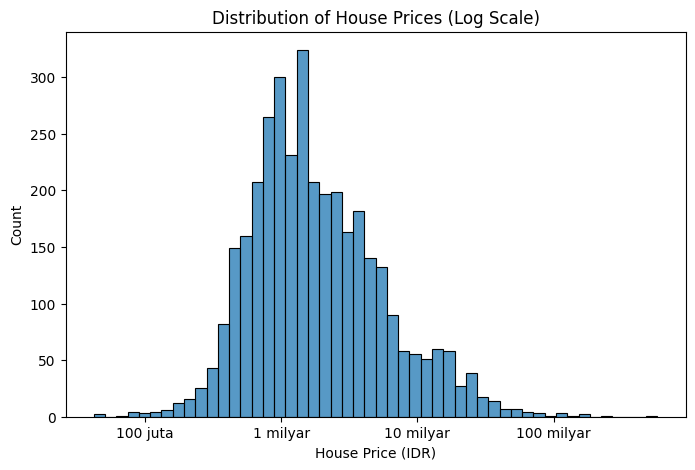

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df["log_price"], bins=50)

plt.title("Distribution of House Prices (Log Scale)")

ticks = [8, 9, 10, 11]

labels = [
    "100 juta",
    "1 milyar",
    "10 milyar",
    "100 milyar"
]

plt.xticks(ticks, labels)

plt.xlabel("House Price (IDR)")
plt.ylabel("Count")

plt.show()

## 6.2 Histogram Variabel Numerik

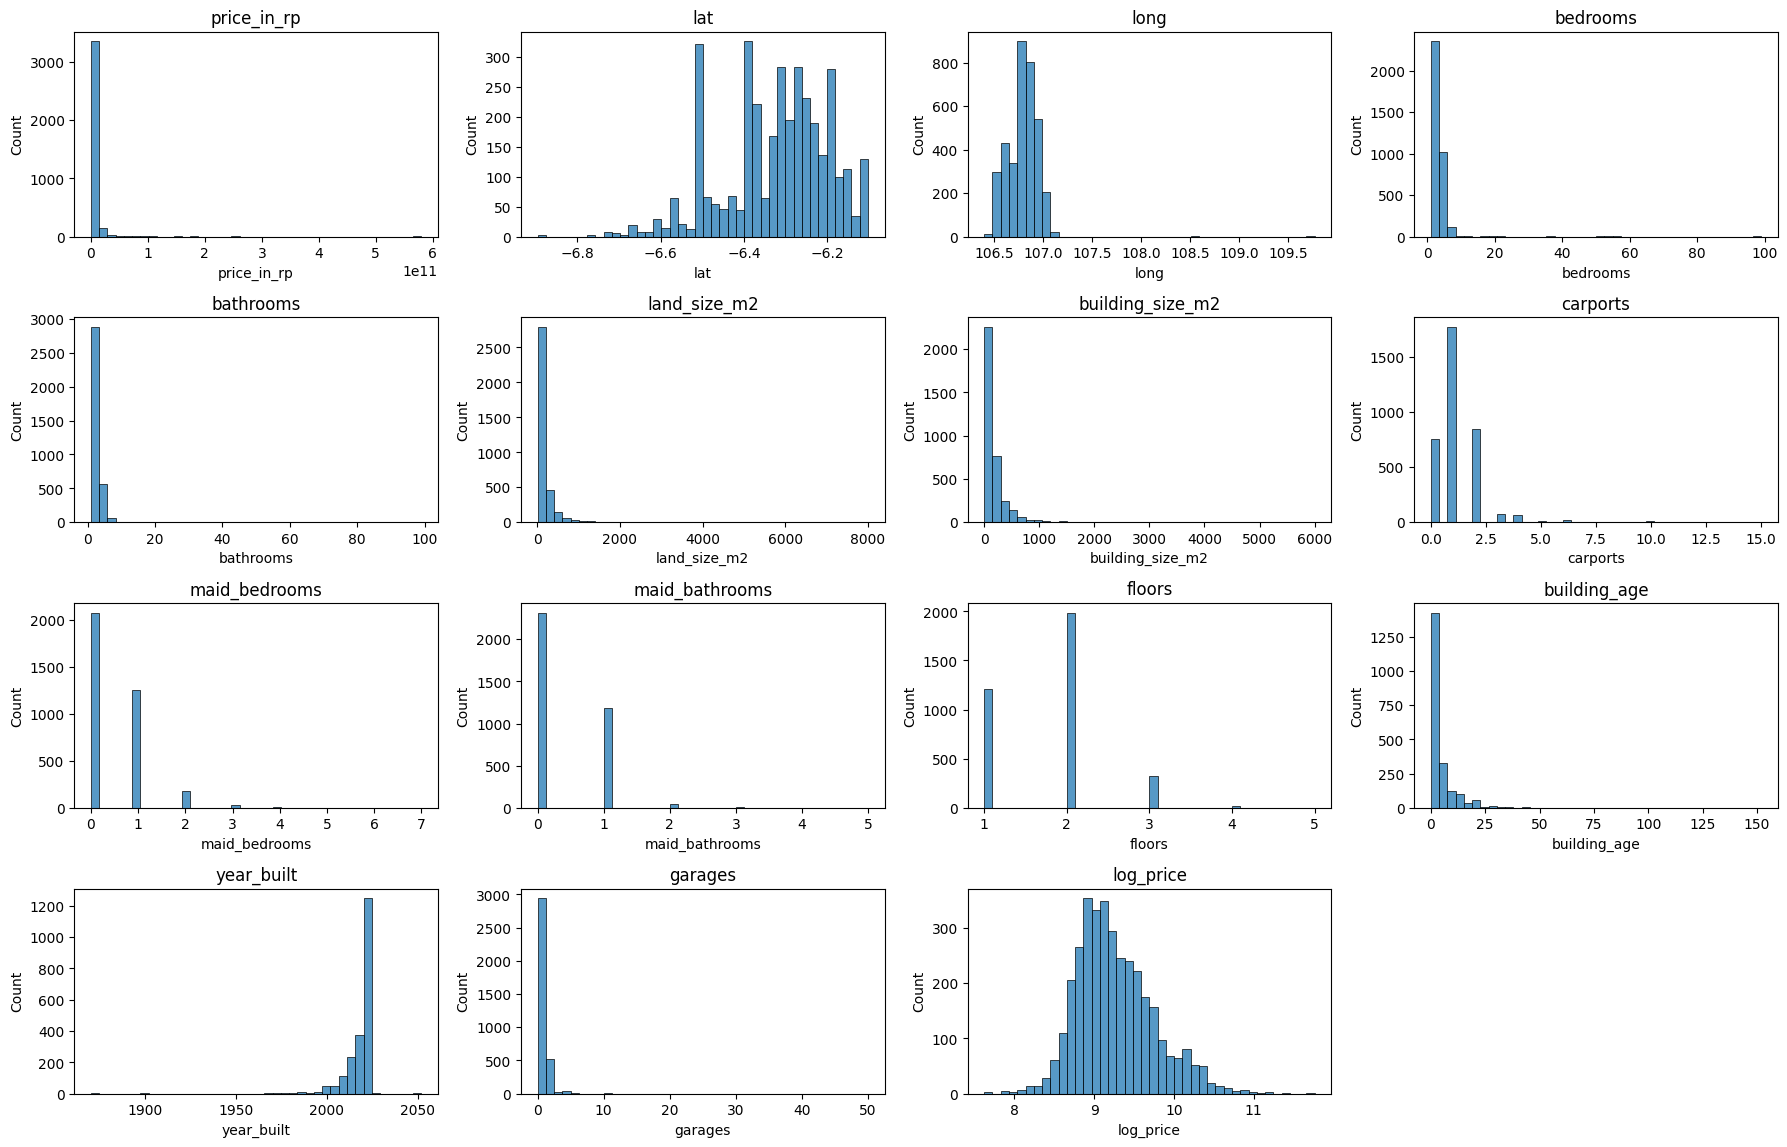

In [13]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

plt.figure(figsize=(18,14))

for i, col in enumerate(numeric_cols):
    
    plt.subplot(5,4,i+1)
    
    sns.histplot(df[col], bins=40)
    
    plt.title(col)

plt.tight_layout()

plt.show()

## 6.3 Correlation Analysis

### 6.3.1 Korelasi Numerik

In [14]:
numeric_df = df.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

corr_matrix

,price_in_rp,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,garages,log_price
price_in_rp,1.000000,0.102572,-0.056809,0.200129,0.231576,0.371807,0.488744,0.220976,0.332851,0.313634,0.150178,0.225134,-0.224767,0.232688,0.512005
lat,0.102572,1.000000,-0.228010,0.058222,0.083657,-0.134335,0.119826,0.000071,0.072258,0.127741,0.233559,0.041958,-0.044894,0.006497,0.222228
long,-0.056809,-0.228010,1.000000,-0.067570,-0.077556,0.006325,-0.070924,-0.017017,-0.081391,-0.135721,-0.185105,-0.001531,0.001767,-0.049783,-0.216388
bedrooms,0.200129,0.058222,-0.067570,1.000000,0.946025,0.243171,0.598723,0.153210,0.190303,0.193911,0.303852,0.144043,-0.144170,0.631609,0.378530
bathrooms,0.231576,0.083657,-0.077556,0.946025,1.000000,0.265643,0.639432,0.182115,0.251309,0.247749,0.372622,0.102499,-0.103009,0.647588,0.442467
land_size_m2,0.371807,-0.134335,0.006325,0.243171,0.265643,1.000000,0.526512,0.390531,0.351973,0.299945,0.085587,0.419900,-0.418656,0.217679,0.488983
building_size_m2,0.488744,0.119826,-0.070924,0.598723,0.639432,0.526512,1.000000,0.329784,0.482675,0.464480,0.380289,0.224439,-0.224393,0.565422,0.691441
carports,0.220976,0.000071,-0.017017,0.153210,0.182115,0.390531,0.329784,1.000000,0.333596,0.316366,0.181921,0.195359,-0.194971,0.145042,0.392244
maid_bedrooms,0.332851,0.072258,-0.081391,0.190303,0.251309,0.351973,0.482675,0.333596,1.000000,0.749572,0.319184,0.290260,-0.290330,0.235770,0.637418
maid_bathrooms,0.313634,0.127741,-0.135721,0.193911,0.247749,0.299945,0.464480,0.316366,0.749572,1.000000,0.363409,0.283175,-0.283380,0.224995,0.642105


### 6.3.2 Korelasi Terhadap Harga Rumah

In [15]:
corr_matrix["price_in_rp"].sort_values(ascending=False)

price_in_rp         1.000000
log_price           0.512005
building_size_m2    0.488744
land_size_m2        0.371807
maid_bedrooms       0.332851
maid_bathrooms      0.313634
garages             0.232688
bathrooms           0.231576
building_age        0.225134
carports            0.220976
bedrooms            0.200129
floors              0.150178
lat                 0.102572
long               -0.056809
year_built         -0.224767
Name: price_in_rp, dtype: float64

### 6.3.3 Visualisasi Heatmap

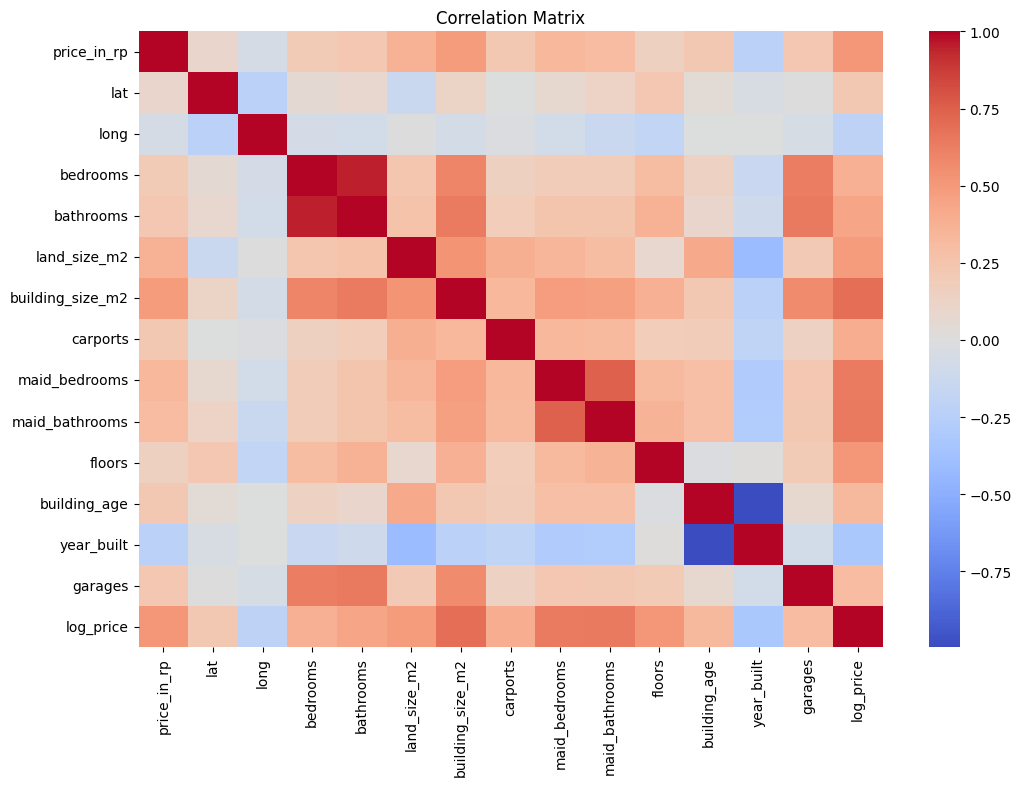

In [16]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## 6.4 Scatter Plot Analysis

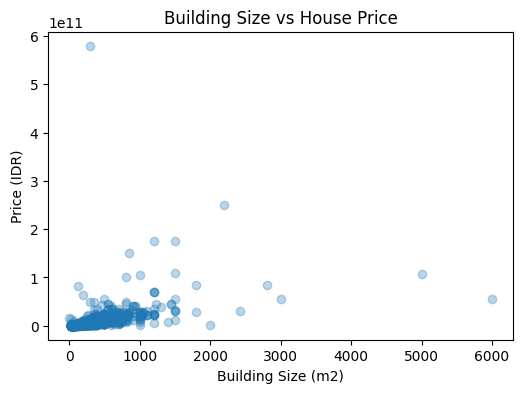

In [17]:
plt.figure(figsize=(6,4))

plt.scatter(df["building_size_m2"], df["price_in_rp"], alpha=0.3)

plt.xlabel("Building Size (m2)")
plt.ylabel("Price (IDR)")
plt.title("Building Size vs House Price")

plt.show()

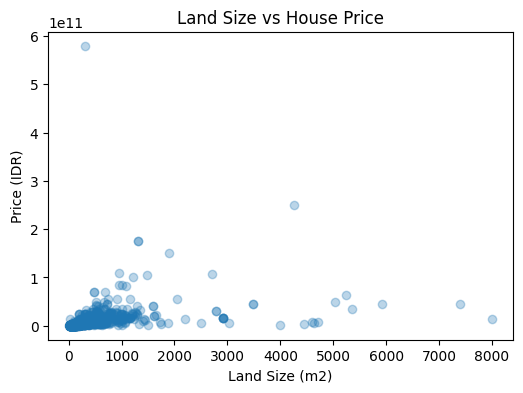

In [18]:
plt.figure(figsize=(6,4))

plt.scatter(df["land_size_m2"], df["price_in_rp"], alpha=0.3)

plt.xlabel("Land Size (m2)")
plt.ylabel("Price (IDR)")
plt.title("Land Size vs House Price")

plt.show()

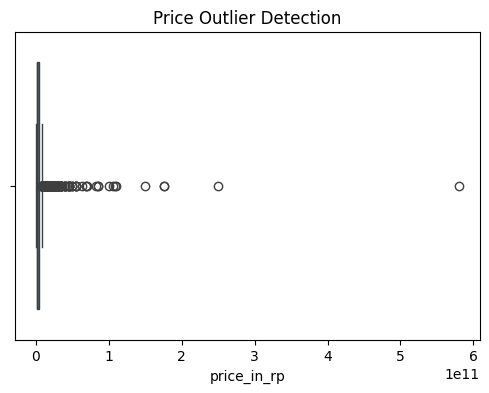

In [19]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["price_in_rp"])

plt.title("Price Outlier Detection")

plt.show()

In [20]:
Q1 = df["price_in_rp"].quantile(0.25)
Q3 = df["price_in_rp"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df["price_in_rp"] >= lower_bound) & (df["price_in_rp"] <= upper_bound)]

In [21]:
print("Data sebelum cleaning:", df.shape)
print("Data setelah cleaning:", df_clean.shape)

Data sebelum cleaning: (3553, 23)
Data setelah cleaning: (3168, 23)


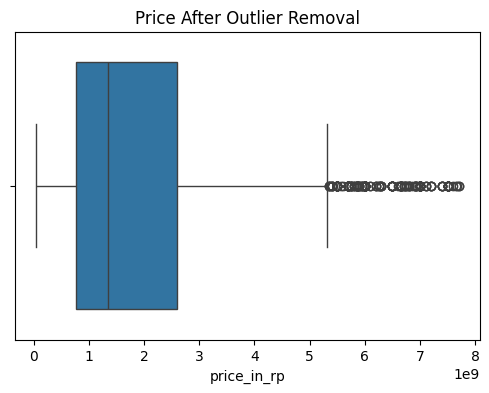

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df_clean["price_in_rp"])

plt.title("Price After Outlier Removal")

plt.show()

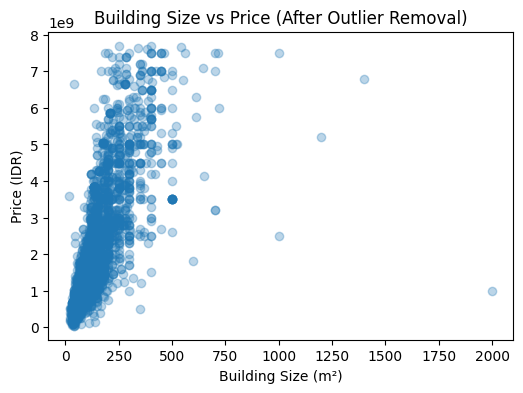

In [23]:
plt.figure(figsize=(6,4))

plt.scatter(df_clean["building_size_m2"], df_clean["price_in_rp"], alpha=0.3)

plt.xlabel("Building Size (m²)")
plt.ylabel("Price (IDR)")
plt.title("Building Size vs Price (After Outlier Removal)")

plt.show()

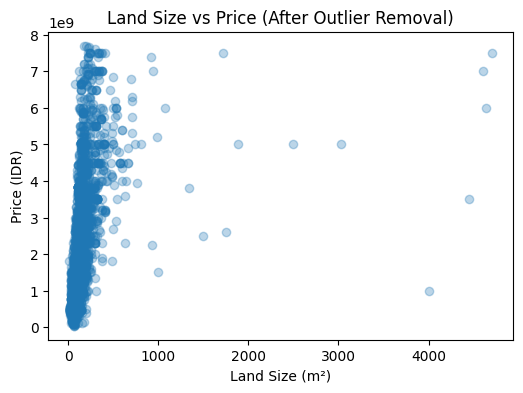

In [24]:
plt.figure(figsize=(6,4))

plt.scatter(df_clean["land_size_m2"], df_clean["price_in_rp"], alpha=0.3)

plt.xlabel("Land Size (m²)")
plt.ylabel("Price (IDR)")
plt.title("Land Size vs Price (After Outlier Removal)")

plt.show()

# 7. DEFINE TARGET AND FEATURES

## 7.1 Tentukan Target

In [25]:
y = df_clean["price_in_rp"]

## 7.2 Tentukan Feature

In [26]:
X = df_clean.drop(["price_in_rp", "log_price"], axis=1)

## 7.3 Cek Struktur Feature

In [27]:
X.head()

,district,city,lat,long,property_type,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,...,electricity,maid_bedrooms,maid_bathrooms,floors,building_age,year_built,property_condition,building_orientation,garages,furnishing
0,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,4.0,4.0,239.0,272.0,0.0,...,4400 mah,0.0,1.0,2.0,5.0,2017.0,bagus,NaN,0.0,unfurnished
1,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,2.0,55.0,69.0,1.0,...,2200 mah,0.0,0.0,2.0,NaN,NaN,bagus,NaN,0.0,NaN
2,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,3.0,119.0,131.0,1.0,...,2200 mah,1.0,1.0,2.0,NaN,NaN,bagus,NaN,1.0,unfurnished
3,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,3.0,3.0,180.0,174.0,0.0,...,3500 mah,1.0,1.0,2.0,6.0,2016.0,bagus sekali,utara,2.0,unfurnished
4,Summarecon Bekasi,Bekasi,-6.223945,106.986275,rumah,4.0,3.0,328.0,196.0,2.0,...,3500 mah,1.0,1.0,2.0,9.0,2013.0,bagus,utara,1.0,unfurnished


# 8. Encode Categorical Variables

## 8.1 Cek Kolom Kategori

In [28]:
X.select_dtypes(include="object").columns

Index(['district', 'city', 'property_type', 'certificate', 'electricity',
       'property_condition', 'building_orientation', 'furnishing'],
      dtype='object')

## 8.2 One Hot Encoding

In [29]:
X = pd.get_dummies(X)

## 8.3 Cek Struktur Feature Baru

In [30]:
X.head()

,lat,long,bedrooms,bathrooms,land_size_m2,building_size_m2,carports,maid_bedrooms,maid_bathrooms,floors,...,building_orientation_barat laut,building_orientation_selatan,building_orientation_tenggara,building_orientation_timur,building_orientation_timur laut,building_orientation_utara,furnishing_baru,furnishing_furnished,furnishing_semi furnished,furnishing_unfurnished
0,-6.223945,106.986275,4.0,4.0,239.0,272.0,0.0,0.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,True
1,-6.223945,106.986275,3.0,2.0,55.0,69.0,1.0,0.0,0.0,2.0,...,False,False,False,False,False,False,False,False,False,False
2,-6.223945,106.986275,3.0,3.0,119.0,131.0,1.0,1.0,1.0,2.0,...,False,False,False,False,False,False,False,False,False,True
3,-6.223945,106.986275,3.0,3.0,180.0,174.0,0.0,1.0,1.0,2.0,...,False,False,False,False,False,True,False,False,False,True
4,-6.223945,106.986275,4.0,3.0,328.0,196.0,2.0,1.0,1.0,2.0,...,False,False,False,False,False,True,False,False,False,True


## 8.4 Cek Jumlah Feature

In [31]:
X.shape

(3168, 415)

## 8.5 Handle Missing Values

In [32]:
# cek missing value
X.isna().sum().sort_values(ascending=False)

building_age                 1283
year_built                   1283
bedrooms                       29
bathrooms                      26
floors                          3
                             ... 
district_BSD Green Wich         0
district_BSD Griya Loka         0
district_BSD Kencana Loka       0
district_BSD Nusaloka           0
district_Tirtajaya              0
Length: 415, dtype: int64

In [33]:
num_cols = X.select_dtypes(include=["int64","float64"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())

In [34]:
cat_cols = X.select_dtypes(include=["bool","object"]).columns

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [35]:
X.isna().sum().sum()

np.int64(0)

# 9. Train-Test Split

## 9.1 Membagi Dataset

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## 9.2 Cek Ukuran Dataset

In [37]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2534, 415)
X_test: (634, 415)
y_train: (2534,)
y_test: (634,)


# 10. Train Model (Linear Regression)

## 10.1 Import Model

In [38]:
from sklearn.linear_model import LinearRegression

## 10.2 Membuat Model

In [39]:
model = LinearRegression()

## 10.3 Melatih Model

In [40]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# 11. Model Prediction

In [41]:
y_pred = model.predict(X_test)

In [42]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
2274,4.100000e+09,5.483845e+09
1171,1.680000e+09,1.765465e+09
170,1.180000e+09,8.576357e+08
3543,7.850000e+08,7.745217e+08
2459,4.550000e+09,2.708470e+09
2018,3.000000e+09,3.060341e+09
412,7.640000e+08,1.127138e+09
458,2.500000e+09,1.718141e+09
3243,7.500000e+08,6.633080e+08
608,5.900000e+09,4.005063e+09


# 12 Evaluasi Model

## 12.1 Mean Absolute Error (MAE)

In [43]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 531957833.49295056


## 12.2 Root Mean Squared Error (RMSE)

In [44]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 1017889176.3949156


In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.show()